In [1]:
# IMDB (1k samples) + DistilRoBERTa Model

import os
import random
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding
from torch.utils.data import DataLoader

SEED = 123
TOTAL_EXAMPLES = 1000
TRAIN_RATIO = 0.8
MODEL_TOKENIZER = "distilroberta-base"
MAX_LEN = 128
BATCH_SIZE = 8
MAP_BATCH_SIZE = 64
NUM_WORKERS = 0
ARTIFACT_DIR = "artifact_friend"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

random.seed(SEED)
torch.manual_seed(SEED)

print("Loading IMDB dataset (train split) ...")
ds = load_dataset("imdb", split="train")
ds = ds.shuffle(seed=SEED).select(range(TOTAL_EXAMPLES))
print(f"Selected {len(ds)} examples (shuffled).")

n_train = int(len(ds) * TRAIN_RATIO)
train_ds = ds.select(range(0, n_train))
val_ds = ds.select(range(n_train, len(ds)))
print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_TOKENIZER, use_fast=True)

def tokenize_fn(batch):

    return tokenizer(batch["text"], truncation=True, padding=False, max_length=MAX_LEN)

print("Tokenizing (batched)...")
train_ds = train_ds.map(tokenize_fn, batched=True, batch_size=MAP_BATCH_SIZE, remove_columns=["text"])
val_ds   = val_ds.map(tokenize_fn, batched=True, batch_size=MAP_BATCH_SIZE, remove_columns=["text"])

columns = ["input_ids", "attention_mask", "label"]
train_ds.set_format(type="torch", columns=columns)
val_ds.set_format(type="torch", columns=columns)

collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collator, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        collate_fn=collator, num_workers=NUM_WORKERS)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Tokenizer type:", type(tokenizer).__name__)
for batch in train_loader:
    print("One batch shapes -> input_ids:", batch["input_ids"].shape,
          "attention_mask:", batch["attention_mask"].shape,
          "labels:", batch["labels"].shape)
    break

def get_data(batch_size=BATCH_SIZE):
    """
    Return fresh DataLoaders and tokenizer for downstream parts.
    Use small batch_size to remain memory safe.
    """
    coll = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")
    t_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=coll, num_workers=NUM_WORKERS)
    v_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=coll, num_workers=NUM_WORKERS)
    return t_loader, v_loader, tokenizer

tokenizer.save_pretrained(os.path.join(ARTIFACT_DIR, "tokenizer_distilroberta"))

print("Part 1 complete — DataLoaders & tokenizer ready.")


Loading IMDB dataset (train split) ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Tokenizing (batched)...


Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Device: cpu
Tokenizer type: RobertaTokenizerFast
One batch shapes -> input_ids: torch.Size([8, 128]) attention_mask: torch.Size([8, 128]) labels: torch.Size([8])
Part 1 complete — DataLoaders & tokenizer ready.


In [2]:

import torch, numpy as np
from torch.optim import AdamW
from tqdm.auto import tqdm
from transformers import AutoModelForSequenceClassification, get_scheduler
import os


train_loader, val_loader, tok = get_data()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Running on:", device)

NUM_LABELS = 2
LRATE = 2e-5
EPOCHS = 1

model_base = AutoModelForSequenceClassification.from_pretrained(
    "distilroberta-base", num_labels=NUM_LABELS
).to(device)

opt = AdamW(model_base.parameters(), lr=LRATE)
num_steps = EPOCHS * len(train_loader)
sched = get_scheduler("linear", optimizer=opt, num_warmup_steps=0, num_training_steps=num_steps)

model_base.train()
progress = tqdm(total=num_steps, desc="Training", leave=False)
for ep in range(EPOCHS):
    loss_sum = 0
    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        out = model_base(**batch)
        loss = out.loss
        opt.zero_grad()
        loss.backward()
        opt.step()
        sched.step()
        loss_sum += loss.item()
        progress.update(1)
    print(f"Epoch {ep+1}/{EPOCHS} → avg loss {loss_sum/len(train_loader):.4f}")
progress.close()

model_base.eval()
preds_all, labs_all = [], []
with torch.no_grad():
    for b in val_loader:
        b = {k: v.to(device) for k, v in b.items()}
        o = model_base(**b)
        preds = torch.argmax(o.logits, dim=-1)
        preds_all.extend(preds.cpu().numpy())
        labs_all.extend(b["labels"].cpu().numpy())

acc_val = np.mean(np.array(preds_all) == np.array(labs_all))
print(f"Validation accuracy: {acc_val*100:.2f}%")

out_dir = os.path.join("artifact_friend", "baseline_model")
os.makedirs(out_dir, exist_ok=True)
model_base.save_pretrained(out_dir)
print("Baseline model stored at", out_dir)

torch.cuda.empty_cache()
print("✅ Part 2 complete — baseline training done.")


Running on: cpu


model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1/1 → avg loss 0.5925
Validation accuracy: 82.00%
Baseline model stored at artifact_friend/baseline_model
✅ Part 2 complete — baseline training done.


In [3]:
# Pruning
import torch, numpy as np, os
import torch.nn.utils.prune as prune
from transformers import AutoModelForSequenceClassification

MODEL_PATH = "artifact_friend/baseline_model"
model_prune = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_prune.to(device).eval()
print("Model ready on:", device)

def size_mb(m):
    torch.save(m.state_dict(), "temp.pt")
    s = os.path.getsize("temp.pt") / (1024 * 1024)
    os.remove("temp.pt")
    return s

size_before = size_mb(model_prune)
print(f"Original model size: {size_before:.2f} MB")

to_prune = [(m, "weight") for m in model_prune.modules() if isinstance(m, torch.nn.Linear)]

prune.global_unstructured(
    to_prune,
    pruning_method=prune.L1Unstructured,
    amount=0.3
)
print("30 % global L1 pruning applied.")

for m, n in to_prune:
    prune.remove(m, n)

_, val_loader, _ = get_data()
all_p, all_l = [], []
with torch.no_grad():
    for b in val_loader:
        b = {k: v.to(device) for k, v in b.items()}
        r = model_prune(**b)
        p = torch.argmax(r.logits, dim=-1)
        all_p.extend(p.cpu().numpy())
        all_l.extend(b["labels"].cpu().numpy())
acc_after = np.mean(np.array(all_p) == np.array(all_l))

size_after = size_mb(model_prune)
print(f"Pruned model size: {size_after:.2f} MB | Val Acc: {acc_after*100:.2f}%")

save_dir = "artifact_friend/pruned_model"
os.makedirs(save_dir, exist_ok=True)
model_prune.save_pretrained(save_dir)
print("Pruned model saved to", save_dir)

torch.cuda.empty_cache()
print("✅ Part 3 complete — model successfully pruned.")


Model ready on: cpu
Original model size: 313.30 MB
30 % global L1 pruning applied.
Pruned model size: 313.30 MB | Val Acc: 75.50%
Pruned model saved to artifact_friend/pruned_model
✅ Part 3 complete — model successfully pruned.


In [4]:
# Quantization
# Converts linear layers to int8

import torch, os, numpy as np
from transformers import AutoModelForSequenceClassification

model_cpu = AutoModelForSequenceClassification.from_pretrained("artifact_friend/pruned_model")
model_cpu.eval()
device = torch.device("cpu")
model_cpu.to(device)

def model_size_mb(model):
    torch.save(model.state_dict(), "temp_q.pt")
    sz = os.path.getsize("temp_q.pt") / (1024 * 1024)
    os.remove("temp_q.pt")
    return sz

before_q = model_size_mb(model_cpu)
print(f"Model size before quantization: {before_q:.2f} MB")

model_int8 = torch.quantization.quantize_dynamic(
    model_cpu,
    {torch.nn.Linear},
    dtype=torch.qint8
)
print("✅ Dynamic quantization applied to Linear layers.")

_, val_loader, _ = get_data()
preds_all, labels_all = [], []
with torch.no_grad():
    for b in val_loader:
        b = {k: v.to(device) for k, v in b.items()}
        o = model_int8(**b)
        p = torch.argmax(o.logits, dim=-1)
        preds_all.extend(p.numpy())
        labels_all.extend(b["labels"].numpy())

acc_q = np.mean(np.array(preds_all) == np.array(labels_all))
after_q = model_size_mb(model_int8)

print(f"Model size after quantization: {after_q:.2f} MB")
print(f"Validation accuracy after quantization: {acc_q*100:.2f}%")

os.makedirs("artifact_friend", exist_ok=True)
torch.save(model_int8.state_dict(), "artifact_friend/quantized_model.pt")
print("Quantized model state saved at artifact_friend/quantized_model.pt")

torch.cuda.empty_cache()
print("✅ Part 4 complete — quantization finished.")


Model size before quantization: 313.30 MB


/tmp/ipython-input-1935452186.py:24: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_int8 = torch.quantization.quantize_dynamic(


✅ Dynamic quantization applied to Linear layers.
Model size after quantization: 190.14 MB
Validation accuracy after quantization: 71.00%
Quantized model state saved at artifact_friend/quantized_model.pt
✅ Part 4 complete — quantization finished.


In [7]:
# Knowledge Distillation
.

import torch, numpy as np, os
import torch.nn.functional as F
from torch.optim import AdamW
from transformers import AutoModelForSequenceClassification
from tqdm.auto import tqdm

train_loader, val_loader, tok = get_data()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Running distillation on:", device)

teacher = AutoModelForSequenceClassification.from_pretrained(
    "artifact_friend/baseline_model"
).to(device)

student = AutoModelForSequenceClassification.from_pretrained(
    "artifact_friend/baseline_model"
).to(device)

for name, param in student.named_parameters():
    if "classifier" not in name:
        param.requires_grad = False

teacher.eval()
for p in teacher.parameters():
    p.requires_grad = False

opt = AdamW(student.parameters(), lr=2e-5)
EPOCHS = 1
alpha = 0.5
temp = 2.0

student.train()
steps = EPOCHS * len(train_loader)
bar = tqdm(range(steps), desc="Distilling", leave=False)

for ep in range(EPOCHS):
    total_loss = 0
    for b in train_loader:
        b = {k: v.to(device) for k, v in b.items()}


        with torch.no_grad():
            t_logits = teacher(**b).logits / temp
            t_probs = F.softmax(t_logits, dim=-1)


        s_out = student(**b)
        s_logits = s_out.logits / temp
        s_probs = F.log_softmax(s_logits, dim=-1)

        loss_soft = F.kl_div(s_probs, t_probs, reduction="batchmean") * (temp**2)
        loss_hard = F.cross_entropy(s_out.logits, b["labels"])
        loss = alpha * loss_hard + (1 - alpha) * loss_soft

        opt.zero_grad()
        loss.backward()
        opt.step()

        total_loss += loss.item()
        bar.update(1)
    print(f"Epoch {ep+1}/{EPOCHS} → avg loss {total_loss/len(train_loader):.4f}")
bar.close()


student.eval()
p_all, l_all = [], []
with torch.no_grad():
    for b in val_loader:
        b = {k: v.to(device) for k, v in b.items()}
        out = student(**b)
        p = torch.argmax(out.logits, dim=-1)
        p_all.extend(p.cpu().numpy())
        l_all.extend(b["labels"].cpu().numpy())
acc_student = np.mean(np.array(p_all) == np.array(l_all))
print(f"Student validation accuracy: {acc_student*100:.2f}%")

save_dir = "artifact_friend/distilled_model"
os.makedirs(save_dir, exist_ok=True)
student.save_pretrained(save_dir)
print("Distilled student model saved at", save_dir)

torch.cuda.empty_cache()
print("✅ Part 5 complete — fixed distillation successful.")


Running distillation on: cpu


Distilling:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1/1 → avg loss 0.1981
Student validation accuracy: 82.50%
Distilled student model saved at artifact_friend/distilled_model
✅ Part 5 complete — fixed distillation successful.


In [8]:
# Summary..

import torch, time, os, numpy as np, pandas as pd
from transformers import AutoModelForSequenceClassification

device = torch.device("cpu")
_, val_loader, _ = get_data()

# ---------- Utilities ----------
def model_size(model):
    torch.save(model.state_dict(), "tmp.pt")
    s = os.path.getsize("tmp.pt") / (1024 * 1024)
    os.remove("tmp.pt")
    return round(s, 2)

def eval_and_time(model):
    model.eval()
    preds, labels = [], []
    start = time.time()
    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            out = model(**batch)
            p = torch.argmax(out.logits, dim=-1)
            preds.extend(p.cpu().numpy())
            labels.extend(batch["labels"].cpu().numpy())
    end = time.time()
    acc = np.mean(np.array(preds) == np.array(labels))
    avg_t = (end - start) / len(val_loader)
    return round(acc * 100, 2), round(avg_t, 4)

print("Evaluating all models on CPU...")

# Baseline, Pruned, Distilled
baseline = AutoModelForSequenceClassification.from_pretrained("artifact_friend/baseline_model").to(device)
pruned = AutoModelForSequenceClassification.from_pretrained("artifact_friend/pruned_model").to(device)
distilled = AutoModelForSequenceClassification.from_pretrained("artifact_friend/distilled_model").to(device)

# Quantized
base_for_q = AutoModelForSequenceClassification.from_pretrained("artifact_friend/pruned_model")
quantized = torch.quantization.quantize_dynamic(base_for_q, {torch.nn.Linear}, dtype=torch.qint8)
print("Dynamic quantized model created in memory.")

models = {
    "Baseline": baseline,
    "Pruned": pruned,
    "Quantized": quantized,
    "Distilled": distilled
}

rows = []
for name, mdl in models.items():
    sz = model_size(mdl)
    acc, tpb = eval_and_time(mdl)
    rows.append((name, sz, acc, tpb))
    print(f"{name:10s} | size={sz:6.2f} MB | acc={acc:5.2f}% | time/batch={tpb:.4f}s")


df = pd.DataFrame(rows, columns=["Model", "Size (MB)", "Val Accuracy (%)", "Time/Batch (s)"])
print("\n📊 Final Comparison Table:")
print(df.to_string(index=False))

os.makedirs("artifact_friend", exist_ok=True)
df.to_csv("artifact_friend/final_summary.csv", index=False)
print("\n✅ Summary saved at artifact_friend/final_summary.csv")


Evaluating all models on CPU...


/tmp/ipython-input-1659318360.py:42: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized = torch.quantization.quantize_dynamic(base_for_q, {torch.nn.Linear}, dtype=torch.qint8)


Dynamic quantized model created in memory.
Baseline   | size=313.30 MB | acc=82.00% | time/batch=1.1326s
Pruned     | size=313.30 MB | acc=75.50% | time/batch=1.1033s
Quantized  | size=190.13 MB | acc=71.00% | time/batch=0.6613s
Distilled  | size=313.30 MB | acc=82.50% | time/batch=1.0591s

📊 Final Comparison Table:
    Model  Size (MB)  Val Accuracy (%)  Time/Batch (s)
 Baseline     313.30              82.0          1.1326
   Pruned     313.30              75.5          1.1033
Quantized     190.13              71.0          0.6613
Distilled     313.30              82.5          1.0591

✅ Summary saved at artifact_friend/final_summary.csv


Evaluating all models on CPU...


/tmp/ipython-input-2603172991.py:41: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized = torch.quantization.quantize_dynamic(base_for_q, {torch.nn.Linear}, dtype=torch.qint8)


Dynamic quantized model created in memory.
Baseline   | size=313.30 MB | acc=82.00% | time/batch=1.0450s
Pruned     | size=313.30 MB | acc=75.50% | time/batch=1.2579s
Quantized  | size=190.13 MB | acc=71.00% | time/batch=0.7907s
Distilled  | size=313.30 MB | acc=82.50% | time/batch=1.6494s

📊 Final table saved at artifact_friend/final_summary.csv


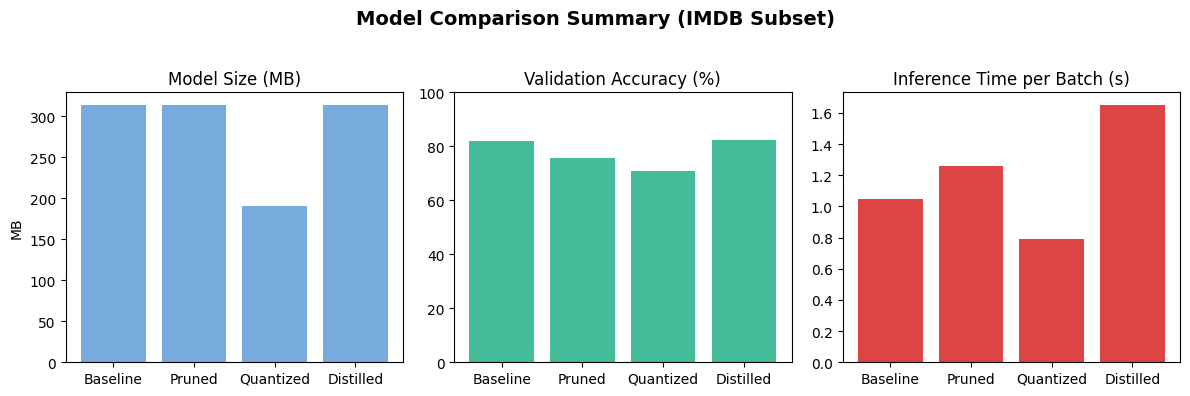

✅ Plot saved at artifact_friend/model_comparison_plot.png


In [9]:

import torch, time, os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from transformers import AutoModelForSequenceClassification

device = torch.device("cpu")
_, val_loader, _ = get_data()

def model_size(model):
    torch.save(model.state_dict(), "tmp.pt")
    s = os.path.getsize("tmp.pt") / (1024 * 1024)
    os.remove("tmp.pt")
    return round(s, 2)

def eval_and_time(model):
    model.eval()
    preds, labels = [], []
    start = time.time()
    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            out = model(**batch)
            p = torch.argmax(out.logits, dim=-1)
            preds.extend(p.cpu().numpy())
            labels.extend(batch["labels"].cpu().numpy())
    end = time.time()
    acc = np.mean(np.array(preds) == np.array(labels))
    avg_t = (end - start) / len(val_loader)
    return round(acc * 100, 2), round(avg_t, 4)

print("Evaluating all models on CPU...")

baseline = AutoModelForSequenceClassification.from_pretrained("artifact_friend/baseline_model").to(device)
pruned = AutoModelForSequenceClassification.from_pretrained("artifact_friend/pruned_model").to(device)
distilled = AutoModelForSequenceClassification.from_pretrained("artifact_friend/distilled_model").to(device)

base_for_q = AutoModelForSequenceClassification.from_pretrained("artifact_friend/pruned_model")
quantized = torch.quantization.quantize_dynamic(base_for_q, {torch.nn.Linear}, dtype=torch.qint8)
print("Dynamic quantized model created in memory.")

models = {
    "Baseline": baseline,
    "Pruned": pruned,
    "Quantized": quantized,
    "Distilled": distilled
}

records = []
for name, mdl in models.items():
    sz = model_size(mdl)
    acc, tpb = eval_and_time(mdl)
    records.append((name, sz, acc, tpb))
    print(f"{name:10s} | size={sz:6.2f} MB | acc={acc:5.2f}% | time/batch={tpb:.4f}s")

df = pd.DataFrame(records, columns=["Model", "Size (MB)", "Val Accuracy (%)", "Time/Batch (s)"])
os.makedirs("artifact_friend", exist_ok=True)
df.to_csv("artifact_friend/final_summary.csv", index=False)
print("\n📊 Final table saved at artifact_friend/final_summary.csv")

plt.figure(figsize=(12, 4))
plt.suptitle("Model Comparison Summary (IMDB Subset)", fontsize=14, fontweight="bold")

plt.subplot(1, 3, 1)
plt.bar(df["Model"], df["Size (MB)"], color="#77aadd")
plt.title("Model Size (MB)")
plt.ylabel("MB")

plt.subplot(1, 3, 2)
plt.bar(df["Model"], df["Val Accuracy (%)"], color="#44bb99")
plt.title("Validation Accuracy (%)")
plt.ylim(0, 100)

plt.subplot(1, 3, 3)
plt.bar(df["Model"], df["Time/Batch (s)"], color="#dd4444")
plt.title("Inference Time per Batch (s)")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("artifact_friend/model_comparison_plot.png", dpi=150)
plt.show()

print("✅ Plot saved at artifact_friend/model_comparison_plot.png")
